# PE 因子单因子检验
## 数据清洗与样本构建


In [34]:
import pandas as pd
import numpy as np
import sqlite3
import statsmodels.api as sm

from plotnine import (
    ggplot, aes, geom_histogram, geom_point, geom_col,
    labs, theme, theme_minimal, element_text
)
from scipy.stats import mstats

import warnings
warnings.filterwarnings("ignore")  # 忽略所有 warning


In [35]:
return_monthly = pd.read_csv(r"D:\stata\TRD_Mnth.csv")
return_monthly = return_monthly.dropna()
return_monthly = return_monthly.rename(columns={
    'Stkcd': 'permno',
    'Trdmnt': 'date',
    'Msmvosd': 'market_value',
    'Mretwd': 'market_return'
})
return_monthly['date'] = pd.to_datetime(return_monthly['date'])
return_monthly.head()


,permno,date,market_value,market_return
0,1,2000-01-01,19843822.88,0.061891
1,1,2000-02-01,19618933.36,-0.011333
2,1,2000-03-01,19672478.48,0.002729
3,1,2000-04-01,20400692.17,0.037017
4,1,2000-05-01,19276244.57,-0.055118


In [36]:
pe_data = pd.read_csv(r"D:\stata\FI_T10.csv").get(['Stkcd', 'Accper', 'F100101B'])
pe_data = pe_data.dropna()
pe_data = pe_data.rename(columns={
    'Stkcd': 'permno',
    'F100101B': 'pe',
    'Accper': 'date'
})
pe_data['date'] = pd.to_datetime(pe_data['date'])
pe_data.head()


,permno,date,pe
0,1,2000-06-30,50.676223
1,1,2000-12-31,55.775813
2,1,2001-06-30,58.810447
3,1,2001-12-31,59.241217
4,1,2002-03-31,53.341275


## 1. 样本概览：2000 年末股票市值分布


In [37]:
stocks_2000_end = return_monthly[return_monthly['date'] == pd.Timestamp('2000-12-01')]
num_stocks_2000 = stocks_2000_end['permno'].nunique()
print(f'2000年末市场上的股票数量为：{num_stocks_2000}')

2000年末市场上的股票数量为：1147


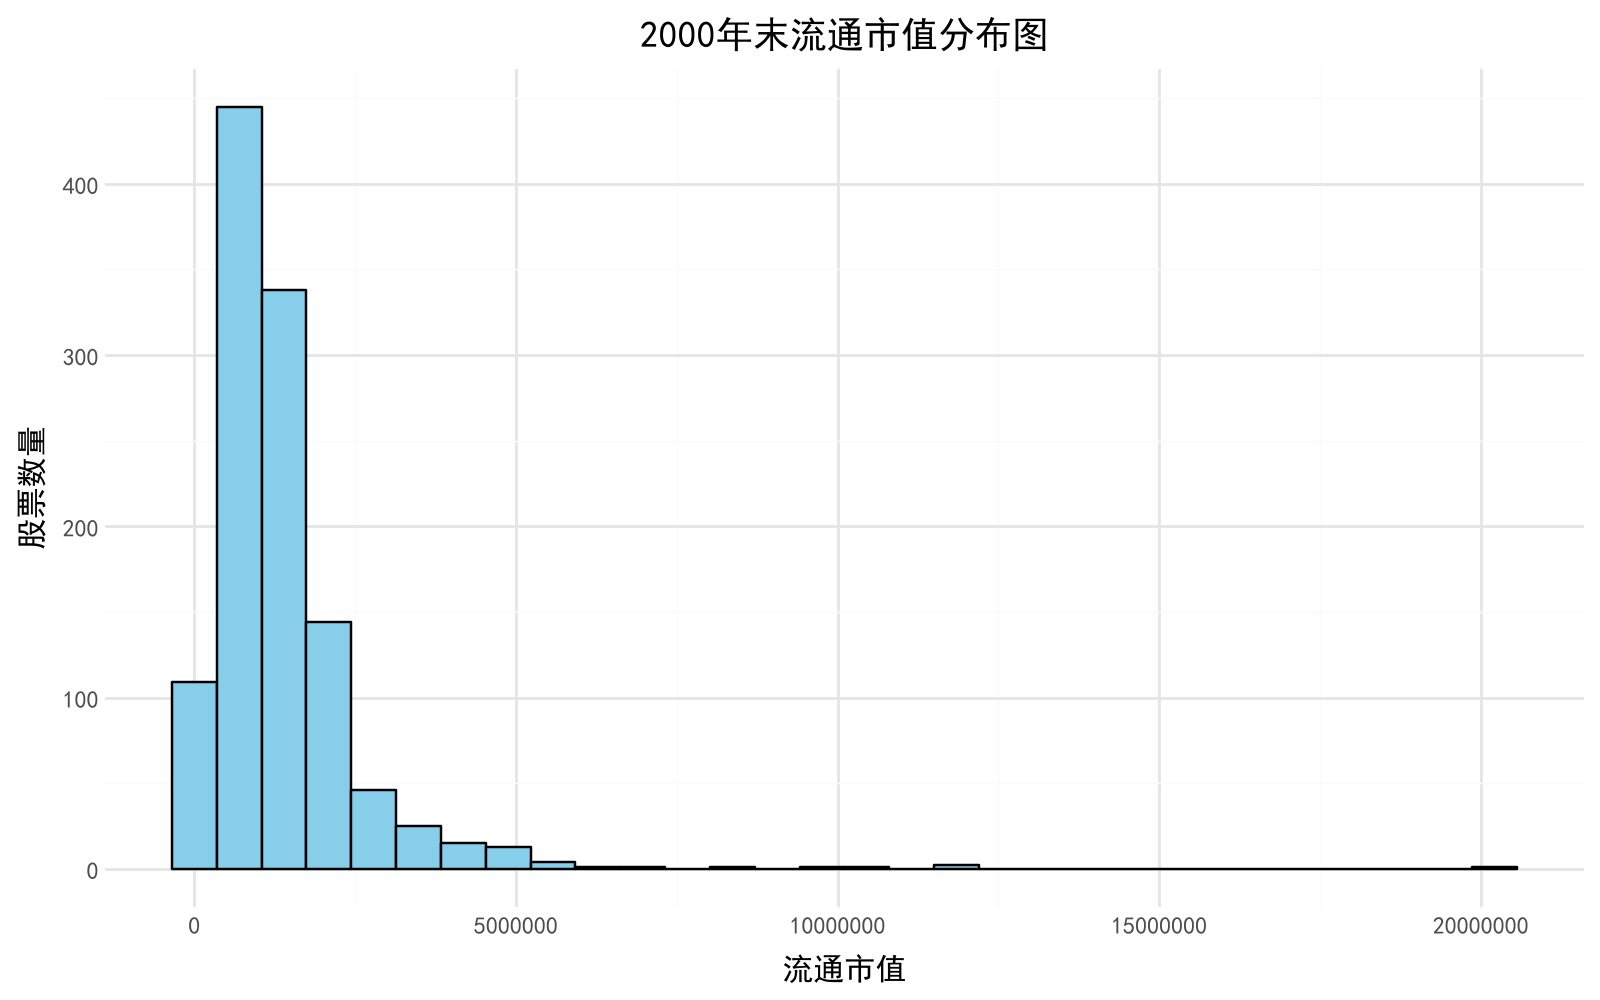

In [38]:
market_value_distribution_plot = (
    ggplot(stocks_2000_end, aes(x='market_value'))
    + geom_histogram(bins=30, fill='skyblue', color='black')
    + labs(
        title='2000年末流通市值分布图',
        x='流通市值',
        y='股票数量'
    )
    + theme_minimal()
    + theme(
        text=element_text(family='SimHei'),
        figure_size=(8, 5)
    )
)

market_value_distribution_plot


2000 年末流通市值呈明显右偏分布，大部分股票集中在较低市值区间，少数公司市值明显更高。这个现象说明 A 股样本在规模上存在较强异质性，后续做 PE 因子检验时需要注意市值暴露可能带来的影响。


## 2. 2000 年末 PE 与 2001 年收益的关系


PE 和收益都可能存在极端值。这里先对 PE 和后续收益做缩尾处理，再绘制散点图，避免少数极端样本主导图形判断。


In [39]:
pe_2000 = pe_data[pe_data['date'] == pd.Timestamp('2000-12-31')][['permno', 'pe']]
pe_2000['pe'] = mstats.winsorize(pe_2000['pe'], limits=[0.05, 0.05])
pe_2000['pe'] = np.log(pe_2000['pe'])

return_2001 = (
    return_monthly[
        (return_monthly['date'] >= pd.Timestamp('2001-01-01')) &
        (return_monthly['date'] <= pd.Timestamp('2001-12-31'))
    ]
    .groupby('permno')['market_return']
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)
return_2001['market_return'] = mstats.winsorize(return_2001['market_return'], limits=[0.01, 0.01])

pe_return_2001 = pd.merge(pe_2000, return_2001, on='permno')
pe_return_2001.head()


,permno,pe,market_return
0,1,4.021340,-0.156336
1,2,3.345241,-0.033812
2,4,4.814090,-0.332425
3,6,3.200453,-0.143345
4,8,5.336474,-0.568082


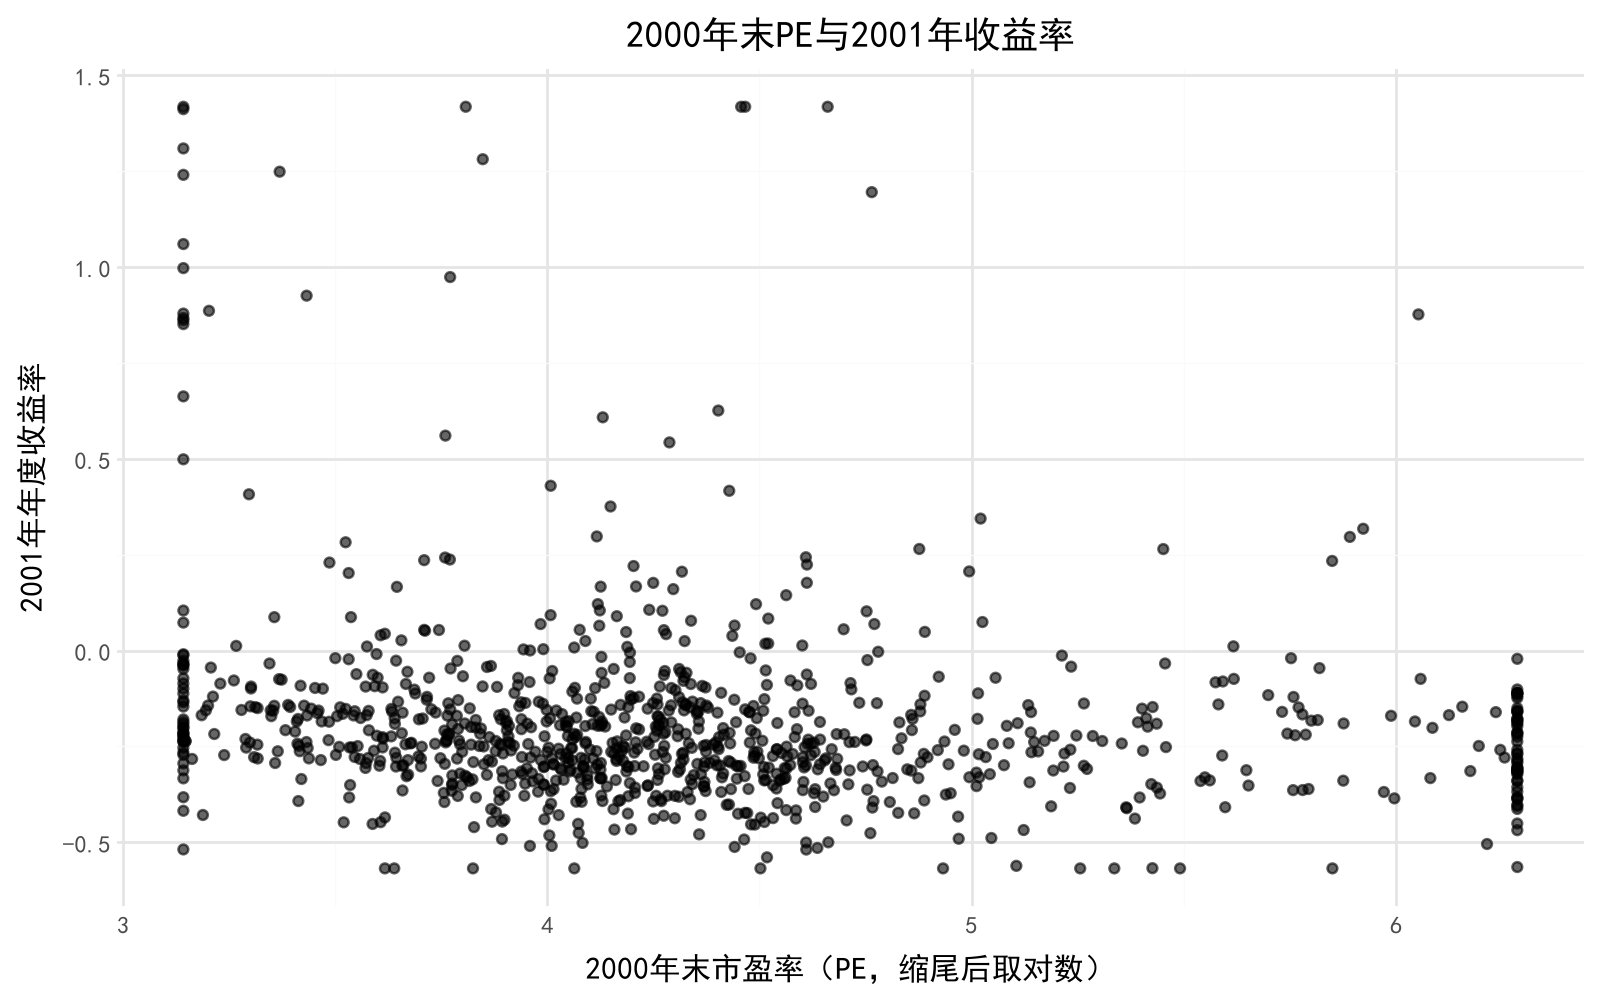

In [40]:
pe_return_scatter_plot = (
    ggplot(pe_return_2001, aes(x='pe', y='market_return'))
    + geom_point(alpha=0.6)
    + labs(
        title='2000年末PE与2001年收益率',
        x='2000年末市盈率（PE，缩尾后取对数）',
        y='2001年年度收益率'
    )
    + theme_minimal()
    + theme(
        text=element_text(family='SimHei'),
        figure_size=(8, 5)
    )
)

pe_return_scatter_plot


散点图显示，低 PE 股票在 2001 年整体收益相对更高，但单只股票层面的离散程度也很明显。因此，仅靠散点图还不能说明 PE 因子稳定有效，需要进一步通过分组组合和跨年份检验来判断。


## 3. 按 PE 构建 10 个分位组合


In [41]:
pe_2000_sorted = pe_2000.sort_values('pe')
pe_2000_sorted['pe_group'] = pd.qcut(pe_2000_sorted['pe'], 10, labels=False) + 1
pe_2000_sorted = pe_2000_sorted.reset_index(drop=True)
pe_2000_sorted

,permno,pe,pe_group
0,900957,3.142219,1
1,900953,3.142219,1
2,34,3.142219,1
3,900949,3.142219,1
4,36,3.142219,1
...,...,...,...
981,929,6.286304,10
982,909,6.286304,10
983,600875,6.286304,10
984,49,6.286304,10


In [42]:
group1 = pe_2000_sorted[pe_2000_sorted['pe_group'] == 1]['permno']
group10 = pe_2000_sorted[pe_2000_sorted['pe_group'] == 10]['permno']
group1.head(), group10.head()

(0    900957
 1    900953
 2        34
 3    900949
 4        36
 Name: permno, dtype: int64,
 887       561
 888    600756
 889    600216
 890       829
 891    600859
 Name: permno, dtype: int64)

第 1 组为低 PE 股票，第 10 组为高 PE 股票。这个分组只基于 2000 年末 PE，用于观察随后一年不同估值组合的收益差异。


## 4. 计算 2001 年各 PE 分位组合收益


In [43]:
pe_return_group_2001 = (
    pd.merge(pe_return_2001, pe_2000_sorted[['permno', 'pe_group']], on='permno')
    .sort_values('pe_group')
    .reset_index(drop=True)
)
pe_return_group_2001.head()


,permno,pe,market_return,pe_group
0,600881,3.215047,-0.217701,1
1,600884,3.349428,-0.171169,1
2,60,3.364749,-0.262740,1
3,61,3.416509,-0.262581,1
4,600270,3.373844,-0.076010,1


In [44]:
group_returns_2001 = (
    pe_return_group_2001
    .groupby('pe_group')['market_return']
    .mean()
    .reset_index()
    .rename(columns={'pe_group': '分位组合', 'market_return': '平均收益'})
)
group_returns_2001


,分位组合,平均收益
0,1,-0.003129
1,2,-0.179107
2,3,-0.173174
3,4,-0.237282
4,5,-0.206357
5,6,-0.190605
6,7,-0.204781
7,8,-0.220800
8,9,-0.254486
9,10,-0.220823


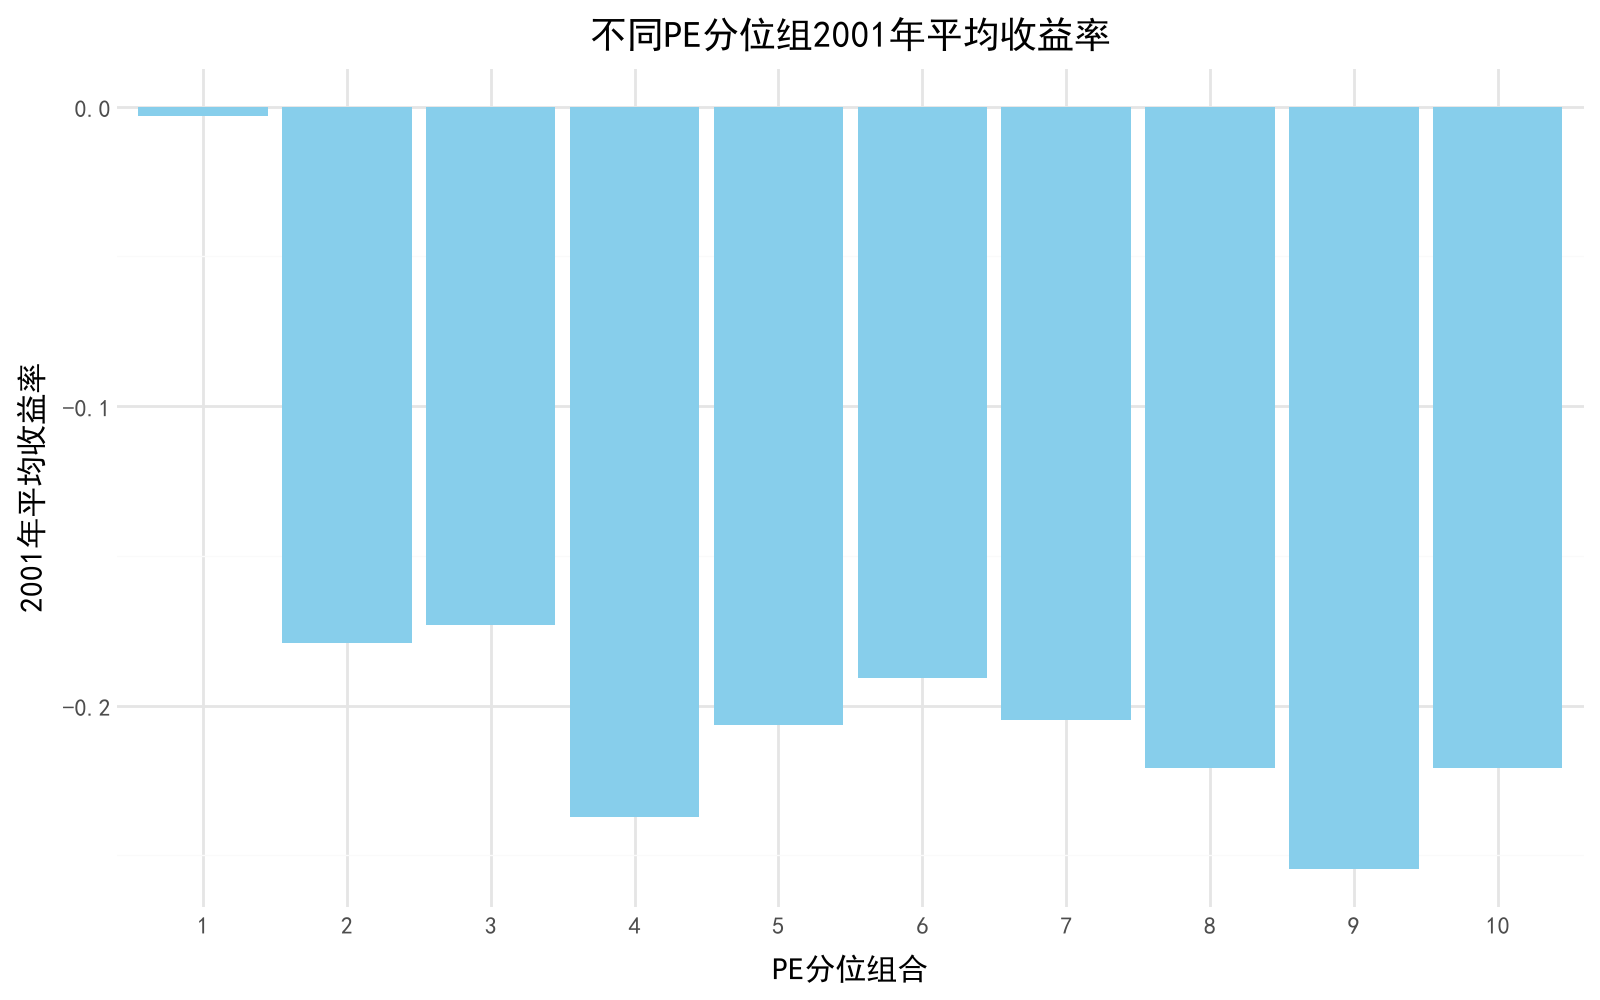

In [45]:
group_returns_2001_plot = (
    ggplot(group_returns_2001, aes(x='factor(分位组合)', y='平均收益'))
    + geom_col(fill='skyblue')
    + labs(
        title='不同PE分位组2001年平均收益率',
        x='PE分位组合',
        y='2001年平均收益率'
    )
    + theme_minimal()
    + theme(
        text=element_text(family='SimHei'),
        figure_size=(8, 5)
    )
)

group_returns_2001_plot


2001 年的结果显示，低 PE 分位组合收益高于高 PE 分位组合，说明该年份 PE 对未来收益有一定区分度。不过这是单一年份结果，仍需要在更长样本期内检验其稳定性。


## 5. 构造低 PE 减高 PE 的零成本组合


In [46]:
long_short_return_2001 = (
    group_returns_2001.loc[group_returns_2001['分位组合'] == 1, '平均收益'].values[0]
    - group_returns_2001.loc[group_returns_2001['分位组合'] == 10, '平均收益'].values[0]
)
long_short_return_2001


np.float64(0.2176940206851479)

## 6. 扩展到 2001-2024 年的年度分组收益


In [55]:
years = range(2001, 2025)
annual_group_returns = []

for year in years:
    annual_returns = (
        return_monthly[
            (return_monthly['date'] >= pd.Timestamp(f'{year}-01-01')) &
            (return_monthly['date'] <= pd.Timestamp(f'{year}-12-31'))
        ]
        .groupby('permno')['market_return']
        .apply(lambda x: (1 + x).prod() - 1)
        .reset_index()
    )
    annual_returns['market_return'] = mstats.winsorize(annual_returns['market_return'], limits=[0.01, 0.01])

    pe_year = pe_data[pe_data['date'] == pd.Timestamp(f'{year-1}-12-31')][['permno', 'pe']]
    pe_year['pe'] = mstats.winsorize(pe_year['pe'], limits=[0.05, 0.05])
    pe_year['pe'] = np.log(pe_year['pe'])
    pe_year_sorted = pe_year.sort_values('pe')
    pe_year_sorted['pe_group'] = pd.qcut(pe_year_sorted['pe'], 10, labels=False) + 1
    pe_year_sorted = pe_year_sorted.reset_index(drop=True)

    annual_data = pd.merge(pe_year_sorted[['permno', 'pe_group']], annual_returns, on='permno')
    group_returns = annual_data.groupby('pe_group')['market_return'].mean().reset_index()
    group_returns['year'] = year
    annual_group_returns.append(group_returns)

annual_group_returns = pd.concat(annual_group_returns)
annual_group_return_pivot = annual_group_returns.pivot(index='year', columns='pe_group', values='market_return')
annual_group_return_pivot['long_short'] = annual_group_return_pivot[1] - annual_group_return_pivot[10]

annual_group_return_pivot


pe_group,1,2,3,4,5,6,7,8,9,10,long_short
year,,,,,,,,,,,
2001,-0.003129,-0.179107,-0.173174,-0.237282,-0.206357,-0.190605,-0.204781,-0.220800,-0.254486,-0.220823,0.217694
2002,-0.144630,-0.142220,-0.167100,-0.222858,-0.218548,-0.219742,-0.208845,-0.227435,-0.195100,-0.202654,0.058024
2003,0.247243,0.086460,-0.042885,-0.102087,-0.133615,-0.162522,-0.180370,-0.222369,-0.195488,-0.248070,0.495313
2004,-0.056982,-0.075297,-0.066020,-0.048294,-0.156175,-0.159748,-0.211899,-0.185899,-0.207939,-0.236588,0.179606
2005,-0.041276,-0.083828,-0.016589,-0.001702,-0.084037,-0.128613,-0.175421,-0.201151,-0.188722,-0.209494,0.168218
2006,1.016804,1.182181,1.103371,1.060265,0.903364,0.989331,0.863591,0.841167,0.913968,0.896322,0.120482
2007,2.499583,2.080642,1.986154,1.906943,1.793670,1.522588,1.733536,2.050283,1.929521,2.090243,0.409340
2008,-0.623385,-0.585868,-0.596248,-0.588631,-0.526347,-0.583827,-0.592012,-0.589312,-0.596972,-0.603027,-0.020359
2009,1.589415,1.557768,1.434749,1.309194,1.277625,1.249030,1.254931,1.377831,1.473770,1.600356,-0.010942


## 7. 各 PE 分位组合的长期平均收益


In [48]:
returns_mean = annual_group_return_pivot.drop(columns=['long_short']).mean(axis=0)
returns_mean_df = (
    returns_mean
    .reset_index()
    .rename(columns={'pe_group': 'PE分位组合', 0: '平均年度收益率'})
)
returns_mean_df['PE分位组合'] = returns_mean_df['PE分位组合'].astype(int)

returns_mean_plot = (
    ggplot(returns_mean_df, aes(x='factor(PE分位组合)', y='平均年度收益率'))
    + geom_col(fill='skyblue')
    + labs(
        title='各PE分位组历年平均收益率',
        x='PE分位组',
        y='平均年度收益率'
    )
    + theme_minimal()
    + theme(
        text=element_text(family='SimHei'),
        figure_size=(8, 5)
    )
)

returns_mean_plot
returns_mean


pe_group
1     0.252489
2     0.224908
3     0.209632
4     0.202632
5     0.179915
6     0.159695
7     0.147962
8     0.153933
9     0.162245
10    0.161251
dtype: float64

从 2001-2024 年的平均结果看，低 PE 分位组合的平均收益整体高于高 PE 分位组合，说明 PE 因子在样本期内具有一定的收益区分能力。但高 PE 组并非单调变差，部分高估值组合仍可能包含成长性较强或行业景气度较高的公司，因此结果应理解为样本内统计关系，而不是无条件成立的交易规则。


## 8. 组合绩效：平均收益、波动率、Sharpe、CAPM Alpha/Beta 与 Newey-West t 值


In [54]:
portfolio_summary = pd.DataFrame({
    '平均收益': annual_group_return_pivot.drop(columns=['long_short']).mean(),
    '标准差': annual_group_return_pivot.drop(columns=['long_short']).std()
})

portfolio_summary['夏普比率'] = portfolio_summary['平均收益'] / portfolio_summary['标准差']

market_monthly_return = (
    return_monthly
    .groupby('date')['market_return']
    .mean()
)
market_return = (
    market_monthly_return
    .groupby(market_monthly_return.index.year)
    .apply(lambda x: (1 + x).prod() - 1)
)

capm_alphas = []
capm_betas = []
newey_west_t = []

for group in annual_group_return_pivot.columns[:-1]:
    reg_data = pd.DataFrame({
        'portfolio_return': annual_group_return_pivot[group],
        'market_return': market_return
    }).replace([np.inf, -np.inf], np.nan).dropna()

    if len(reg_data) < 3:
        capm_alphas.append(np.nan)
        capm_betas.append(np.nan)
        newey_west_t.append(np.nan)
        continue

    y = reg_data['portfolio_return']
    x = sm.add_constant(reg_data['market_return'])
    model = sm.OLS(y, x)
    capm_result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    capm_alphas.append(capm_result.params['const'])
    capm_betas.append(capm_result.params['market_return'])
    newey_west_t.append(capm_result.tvalues['const'])

portfolio_summary['CAPM alpha'] = capm_alphas
portfolio_summary['CAPM beta'] = capm_betas
portfolio_summary['Newey-West t值'] = newey_west_t

portfolio_summary


,平均收益,标准差,夏普比率,CAPM alpha,CAPM beta,Newey-West t值
pe_group,,,,,,
1,0.252489,0.648946,0.389076,0.031297,0.942999,1.021911
2,0.224908,0.600859,0.374311,0.015046,0.894696,0.717497
3,0.209632,0.577739,0.362849,0.006326,0.866746,0.351284
4,0.202632,0.563852,0.359371,0.003434,0.849232,0.180615
5,0.179915,0.545797,0.329636,-0.013600,0.825001,-0.878302
6,0.159695,0.523781,0.304888,-0.023750,0.782068,-1.175582
7,0.147962,0.545607,0.271188,-0.045719,0.825710,-3.142697
8,0.153933,0.601080,0.256094,-0.060312,0.913381,-4.545975
9,0.162245,0.597267,0.271646,-0.050257,0.905946,-4.064801


低 PE 组合在样本期内表现相对更好，平均收益和风险调整后收益整体占优；高 PE 组合的表现相对较弱。这个结果支持 A 股样本中存在一定的低估值溢价，但仍需要结合市值、行业、流动性和交易成本进一步判断其可交易性。


## 9. CAPM 回归结果解释


CAPM 回归结果表明，低 PE 组合在控制市场收益后仍有较好的 alpha 表现，而高 PE 组合的风险调整后表现较弱。这个现象说明 PE 因子不仅反映了市场 beta 差异，也可能包含一定的估值补偿或错误定价成分。

需要注意的是，本检验以年度组合收益为频率，样本量有限，且尚未控制行业、市值和流动性等因素。因此，这里更适合将结果理解为“PE 因子在样本期内具有一定解释力”，而不是直接证明低 PE 策略可以稳定获得超额收益。


## 10. 附加检验：市值加权组合


In [50]:
years = range(2001, 2025)
value_weighted_group_returns = []

for year in years:
    annual_returns = (
        return_monthly[
            (return_monthly['date'] >= pd.Timestamp(f'{year}-01-01')) &
            (return_monthly['date'] <= pd.Timestamp(f'{year}-12-31'))
        ]
        .groupby('permno')
        .agg(
            market_return=('market_return', lambda x: (1 + x).prod() - 1),
            market_value=('market_value', 'mean')
        )
        .reset_index()
    )
    annual_returns['market_return'] = mstats.winsorize(annual_returns['market_return'], limits=[0.01, 0.01])
    annual_returns['market_value'] = mstats.winsorize(annual_returns['market_value'], limits=[0.01, 0.01])

    pe_year = pe_data[pe_data['date'] == pd.Timestamp(f'{year-1}-12-31')][['permno', 'pe']]
    pe_year['pe'] = mstats.winsorize(pe_year['pe'], limits=[0.05, 0.05])
    pe_year['pe'] = np.log(pe_year['pe'])
    pe_year_sorted = pe_year.sort_values('pe')
    pe_year_sorted['pe_group'] = pd.qcut(pe_year_sorted['pe'], 10, labels=False) + 1
    pe_year_sorted = pe_year_sorted.reset_index(drop=True)

    annual_data = pd.merge(pe_year_sorted[['permno', 'pe_group']], annual_returns, on='permno')
    group_returns = (
        annual_data
        .groupby('pe_group')
        .apply(lambda x: np.average(x['market_return'], weights=x['market_value']))
        .reset_index(name='market_return')
    )
    group_returns['year'] = year
    value_weighted_group_returns.append(group_returns)

value_weighted_group_returns = pd.concat(value_weighted_group_returns)
value_weighted_return_pivot = value_weighted_group_returns.pivot(index='year', columns='pe_group', values='market_return')
value_weighted_return_pivot['long_short'] = value_weighted_return_pivot[1] - value_weighted_return_pivot[10]

value_weighted_return_pivot


pe_group,1,2,3,4,5,6,7,8,9,10,long_short
year,,,,,,,,,,,
2001,-0.110408,-0.203730,-0.216149,-0.240442,-0.206604,-0.164025,-0.225537,-0.243769,-0.262898,-0.241693,0.131285
2002,-0.127949,-0.144242,-0.138021,-0.221795,-0.206173,-0.209361,-0.162158,-0.184707,-0.176015,-0.171089,0.043140
2003,0.318273,0.151303,0.017101,-0.006743,-0.061579,-0.111735,-0.105654,-0.199157,-0.134825,-0.202073,0.520346
2004,-0.008827,-0.082181,-0.091950,-0.005440,-0.182508,-0.121099,-0.188451,-0.169868,-0.231278,-0.230395,0.221567
2005,-0.021972,0.028017,0.041268,0.043214,-0.083027,-0.116254,-0.155994,-0.184920,-0.201810,-0.232995,0.211023
2006,1.166625,1.493730,1.300167,1.534925,1.024245,1.321428,1.416603,1.111578,1.183536,1.094592,0.072033
2007,2.658218,2.155455,2.183408,2.027677,1.725362,1.568944,1.529114,2.042253,2.105826,2.173882,0.484336
2008,-0.656200,-0.601459,-0.598385,-0.597402,-0.586757,-0.599599,-0.586734,-0.610272,-0.609086,-0.579332,-0.076867
2009,1.476159,1.311857,1.115593,1.210367,1.119372,1.049656,1.096768,1.206493,1.272272,1.405094,0.071065


## 11. FF3 因子调整后的 Alpha


In [51]:
ff3_factors = pd.read_csv(r"D:\stata\For Students\csv\factors_ff3_monthly.csv")
ff3_factors['date'] = pd.to_datetime(ff3_factors['date'])
ff3_factors['year'] = ff3_factors['date'].dt.year
ff3_yearly = (
    ff3_factors
    .groupby('year')[['mkt_excess', 'smb', 'hml']]
    .apply(lambda x: (1 + x).prod() - 1)
    .reset_index()
)
ff3_yearly.head()


,year,mkt_excess,smb,hml
0,1960,-0.014358,-0.026559,-0.055436
1,1961,0.243226,0.012610,0.043821
2,1962,-0.125753,-0.082881,0.093100
3,1963,0.173552,-0.051773,0.140949
4,1964,0.121458,-0.008589,0.089348


In [52]:
ff3_yearly = ff3_yearly[ff3_yearly['year'].isin(annual_group_return_pivot.index)]
ff3_yearly = ff3_yearly.set_index('year')

ff3_alphas = []

for group in annual_group_return_pivot.columns[:-1]:
    reg_data = (
        pd.DataFrame({'portfolio_return': annual_group_return_pivot[group]})
        .join(ff3_yearly[['mkt_excess', 'smb', 'hml']], how='inner')
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(reg_data) < 5:
        ff3_alphas.append(np.nan)
        continue

    y = reg_data['portfolio_return']
    X = sm.add_constant(reg_data[['mkt_excess', 'smb', 'hml']])
    model = sm.OLS(y, X)
    ff3_result = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})
    ff3_alphas.append(ff3_result.params['const'])

ff3_alpha_summary = pd.DataFrame({'FF3 alpha': ff3_alphas}, index=annual_group_return_pivot.columns[:-1])
ff3_alpha_summary


,FF3 alpha
pe_group,
1,0.251970
2,0.210632
3,0.197100
4,0.193672
5,0.173575
6,0.145822
7,0.142286
8,0.166006
9,0.167207
